In [1]:
# ゲート付きRNN
# RNNの問題点
# RNNの復習
# 勾配消失・勾配爆発
# 勾配消失・勾配爆発の原因

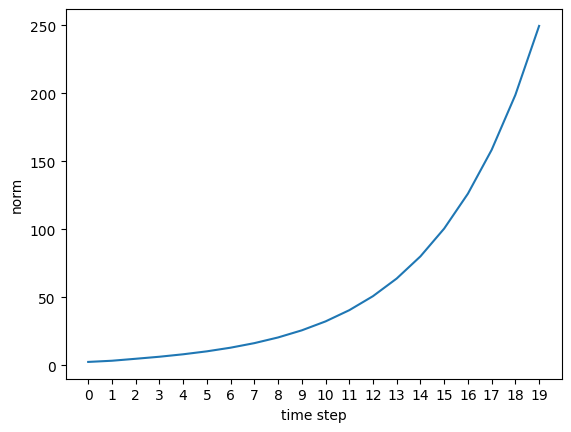

In [2]:
import numpy as np
import matplotlib.pyplot  as plt

N = 2    # ミニバッチサイズ
H = 3    # 隠れ状態ベクトルの次元数
T = 20   # 時系列データの長さ

dh = np.ones((N, H))
np.random.seed(3)
Wh = np.random.randn(H, H)

norm_list = []
for t in range(T):
    dh = np.dot(dh, Wh.T)
    norm = np.sqrt(np.sum(dh**2)) / N
    norm_list.append(norm)

plt.plot(np.arange(len(norm_list)), norm_list)
plt.xticks(np.arange(len(norm_list)))
plt.xlabel("time step")
plt.ylabel("norm")
plt.show()

In [3]:
# 勾配爆発への対策
# 勾配クリッピング
dW1 = np.random.rand(3, 3) * 10
dW2 = np.random.rand(3, 3) * 10
grads = [dW1, dW2]  # 重みをまとめる
max_norm = 5.0  # 勾配の大きさの上限値

def clip_grads(grads, max_norm):
    total_norm = 0
    for grad in grads:
        total_norm += np.sum(grad ** 2)
    total_norm = np.sqrt(total_norm)

    # 上限値 ÷ 現在の大きさを計算
    # 1e-6：ゼロ除算するのを防ぐために足す
    rate = max_norm / (total_norm + 1e-6)
    # もし今の大きさが上限値を超えていたら、
    # 全ての勾配にrateを掛けて小さくする
    if rate < 1:
        for grad in grads:
            grad *= rate

clip_grads(grads, max_norm)

In [4]:
# 勾配消失とLSTM
# LSTMのインタフェース
# LSTMレイヤの組み立て
# outputゲート
# forgetゲート
# 新しい記憶セル
# inputゲート
# LSTMの勾配の流れ

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class LSTM:
    def __init__(self, Wx, Wh, b):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.cache = None

    def forward(self, x, h_prev, c_prev):
        # 共通の重みを取り出す
        Wx, Wh, b = self.params
        # N：バッチサイズ
        # H：隠れ状態 
        # ➡ f, g, i, oを4等分する時に使う
        # h_prev：直前の出力（1つ前の時刻で、最終的に出力された情報）
        N, H = h_prev.shape

        A = np.dot(x, Wx) + np.dot(h_prev, Wh) + b

        # slice
        f = A[:, :H]         # 最初からH番目まで、
        g = A[:, H:2*H]      # H番目から2倍のH番目まで、
        i = A[:, 2*H:3*H]    # 2倍のH番目から3倍のH番目まで、
        o = A[:, 3*H:]       # 3倍のH番目から最後まで、を切り出す　　　　

        f = sigmoid(f)
        g = np.tanh(g)
        i = sigmoid(i)
        o = sigmoid(o)

        # 古い記憶を整理して、新しい記憶を付け足す
        # c_prev：知識のストック（1つ前の時刻までに蓄積されてきた、加工前の生データ）
        # f * c_prev：「忘却ゲート」と「これまでの記憶」のかけ算(fが0なら消える、1ならそのまま残る)
        # g * i：「新しい情報」に「入力ゲート」のかけ算
        # 新しく入ってきた情報のうち、どれくらい覚えるかを計算
        c_next = f * c_prev + g * i
        # np.tanh(c_next)：生データを-1.0 ~ 1.0の範囲に整える
        # o * ...：整えた値に、出力ゲートを掛ける
        # ➡ 次の層に渡すべき情報なのかを判断し、h_nextが最終的な答えになる
        h_next = o * np.tanh(c_next)

        # 逆伝播するとき用に、順伝播の情報をメモする
        self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
        # 「新しい隠れ状態（h）」と「新しい記憶（c）」を、次の層へ
        return h_next, c_next


In [6]:
# TimeLSTMの実装
class TimeLSTM:
    def __init__(self, Wx, Wh, b, stateful=False):
        self.params = [Wx, Wh, b]
        self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
        self.layers = None

        self.h, self.c = None, None
        self.dh = None  # 逆伝播の時に、1つ前の時刻から伝わってくる勾配を一時的に保管する場所
        self.stateful = stateful

    def forward(self, xs):
        Wx, Wh, b = self.params  # 共通の重みを受け取る
        # N：バッチサイズ
        # T：Time（時系列の長さ、何単語分のセットか）
        #D：入力データの次元数
        N, T, D = xs.shape
        # Whの重みのサイズを測り、隠れ状態のサイズを調べる
        H = Wh.shape[0]

        # layerを入れる箱を用意
        self.layers = []
        # 中身は何でも良いので、
        # N × T × H分のメモリ領域を確保する
        hs = np.empty((N, T, H), dtype="f")
        
        # not self.stateful：記憶を引き継がないなら、
        # self.h is None：まだ一度も計算していないなら、
        if not self.stateful or self.h is None:
            # self.hをリセット
            self.h = np.zeros((N, H), dtype="f") 
        if not self.stateful or self.c is None:
            # self.c：前層までの記憶を引き継いだメモ
            # バッチサイズ分の隠れ状態のサイズをメモする
            self.c = np.zeros((N, H), dtype="f")

        for t in range(T):
            # 使い捨てのLSTMを作成（T個分繰り返す）
            # *self.params：[Wx, Wh, b]をバラバラにして渡す
            layer = LSTM(*self.params)
            # xs[:, t, :]：全員のデータの「時刻t」だけを取り出して渡す
            # self.h, self.c：前の時刻から回ってきたバトンを渡す
            self.h, self.c = layer.forward(xs[:, t, :], self.h, self.c)
            # np.emptyで用意したhsの、時刻ｔに、self.hを全員分書き込む
            hs[:, t, :] = self.h
            
            # 逆伝播用に、計算で使った変数をメモしておく
            self.layers.append(layer)

        return hs

    def backward(self, dhs):
        # 重みを受け取る
        Wx, Wh, b = self.params
        # hsに対する勾配をTステップ分受け取る
        N, T, H = dhs.shape
        # Wxのサイズを測り、D（入力の次元数）の箱を作成
        D = Wx.shape[0]

        # Tステップ分の勾配を入れるための箱を用意
        dxs = np.empty((N, T, D), dtype="f")
        # 勾配０スタート（時刻Tより先はないから）
        dh, dc = 0, 0

        grads = [0, 0, 0]
        # 後ろの時刻から順番に呼び出して逆伝播実行
        for t in reversed(range(T)):
            # 順伝播時に、appendで保存していた、時刻Tの使い捨てレイヤをリストから取り出す
            # layersには、その時の計算メモ（cache）が保存されている
            layer = self.layers[t]
            # dhs[:, t, :]：出力側から降ってきた勾配
            dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
            dxs[:, t, :] = dx
            for i, grad in enumerate(layer.grads):
                grads[i] += grad

        for i, grad in enumerate(grads):
            self.grads[i][...] = grad
            self.dh = dh
            return dxs

    def set_state(self, h, c=None):
        self.h, self.c = h, c

    def reset_state(self):
        self.h, self.c = None, None

In [7]:
# LSTMを使った言語モデル
# Rnnlmクラスの実装
import sys
sys.path.append("..")
from common.time_layers import *
import pickle

class Rnnlm:
    def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        # 重みの初期化
        # 単語（V個）を単語ベクトル（D次元）に変換する辞書
        embed_W = (rn(V, D) / 100).astype("f")
        # 単語入力（D）をLSTMの4つのゲート用（4 × H）に変換する重み
        lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype("f")
        # 前の記憶（H）を次の4つのゲート用（4 × H）に変換する重み
        lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_b = np.zeros(4 * H).astype("f")
        # 最終的な記憶（H）を全単語（V個）のスコアに変換する重み
        affine_W = (rn(H, V) / np.sqrt(H)).astype("f")
        affine_b = np.zeros(V).astype("f")

        # レイヤの生成
        self.layers = [
            TimeEmbedding(embed_W),
            TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True),
            TimeAffine(affine_W, affine_b)
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        self.lstm_layer = self.layers[1]

        # 全ての重みと勾配をリストにまとめる
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs):
        # このfor文で次のようにデータが流れる
        # １. TimeEmbedding：数字のIDだった単語を受け取って、意味ベクトルに変換 ➡ 次の層へ
        # ２. TimeLSTM：self.hとself.cを書き換えて、記憶を更新していく
        # ３. TimeAffine：LSTMが出した情報を、最終的なスコアに変換する
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs
    
    def forward(self, xs, ts):
        # predictで求めた最終的なスコアを取り出す
        score = self.predict(xs)
        # AIのscoreと、正解データ（ts）を照らし合わせて損失を出す
        loss = self.loss_layer.forward(score, ts)
        return loss


    def backward(self, dout=1):
        # forwardで求めたlossを取り出し、勾配を計算する
        dout = self.loss_layer.backward(dout)
        # forwardと逆順で層を回る
        for layer in reversed(self.layers):
            # 各レイヤに、勾配を渡し、次のレイヤに渡す勾配を求める
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        # 記憶のリセット
        # 「h」と「c」を0の行列に戻す
        self.lstm_layer.reset_state()

    def save_params(self, file_name="Rnnlm.pkl"):
        with open(file_name, "wb") as f:
            pickle.dump(self.params, f)

    def load_params(self, file_name="Rnnlm.pkl"):
        with open(file_name, "rb") as f:
            self.params = pickle.load(f)

| epoch 1 |  iter 1 / 1327 | time 0[s] | perplexity 9999.62
| epoch 1 |  iter 21 / 1327 | time 2[s] | perplexity 2977.73
| epoch 1 |  iter 41 / 1327 | time 5[s] | perplexity 1227.87
| epoch 1 |  iter 61 / 1327 | time 8[s] | perplexity 986.29
| epoch 1 |  iter 81 / 1327 | time 11[s] | perplexity 791.87
| epoch 1 |  iter 101 / 1327 | time 14[s] | perplexity 667.94
| epoch 1 |  iter 121 / 1327 | time 16[s] | perplexity 635.25
| epoch 1 |  iter 141 / 1327 | time 19[s] | perplexity 596.60
| epoch 1 |  iter 161 / 1327 | time 22[s] | perplexity 584.13
| epoch 1 |  iter 181 / 1327 | time 25[s] | perplexity 581.28
| epoch 1 |  iter 201 / 1327 | time 28[s] | perplexity 494.75
| epoch 1 |  iter 221 / 1327 | time 31[s] | perplexity 486.32
| epoch 1 |  iter 241 / 1327 | time 34[s] | perplexity 441.85
| epoch 1 |  iter 261 / 1327 | time 36[s] | perplexity 463.22
| epoch 1 |  iter 281 / 1327 | time 39[s] | perplexity 454.09
| epoch 1 |  iter 301 / 1327 | time 42[s] | perplexity 390.78
| epoch 1 |  it

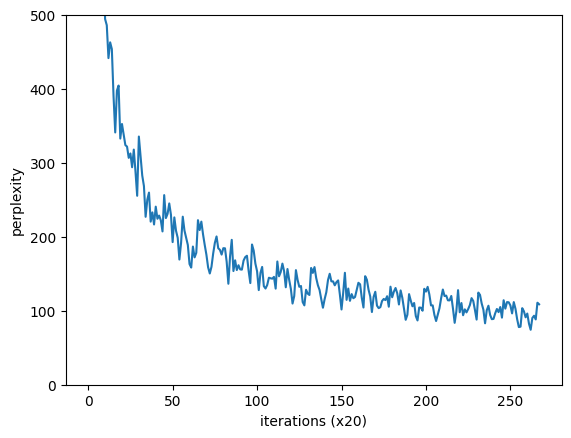

evaluating perplexity ...
234 / 235
test perplexity： 135.08423707355794


In [10]:
import sys
sys.path.append("..")
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity
from dataset import ptb
from rnnlm import Rnnlm

# ハイパーパラメータの設定
batch_size = 20
wordvec_size = 100  # RNNの隠れ状態ベクトルの要素数
hidden_size = 100
time_size = 35  # RNNを展開するサイズ
lr = 20.0
max_epoch = 4
max_grad = 0.25

# 学習データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data("train")
corpus_test, _, _ = ptb.load_data("test")
vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

# モデルの生成
model = Rnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

# 勾配クリッピングを適用して学習
trainer.fit(xs, ts, max_epoch, batch_size, time_size, max_grad, eval_interval=20)
trainer.plot(ylim=(0, 500))

# テストデータで評価
model.reset_state()
ppl_test = eval_perplexity(model, corpus_test)
print("test perplexity：", ppl_test)

# パラメータの保存
model.save_params()

In [11]:
# RNNLMのさらなる改善
# LSTMレイヤの多層化
# Dropoutによる過学習の抑制
# 重み共有

In [ ]:
# より良いRNNLMの実装
import sys
sys.path.append("..")
from common.time_layers import *
from common.np import *
from common.base_model import BaseModel

class BetterRnnlm(BaseModel):
    def __init__(self, vocab_size=10000, wordvec_size=650, hidden_size=650, dropout_ratio=0.5):
        V, D, H = vocab_size, wordvec_size, hidden_size
        rn = np.random.randn

        embed_W = (rn(V, D) / 100).astype("f")
        lstm_Wx1 = (rn(D, 4 * H) / np.sqrt(D)).astype("f")
        lstm_Wh1 = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_b1 = np.zeros(4 * H).astype("f")
        lstm_Wx2 = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_Wh2 = (rn(H, 4 * H) / np.sqrt(H)).astype("f")
        lstm_b2 = np.zeros(4 * H).astype("f")
        affine_b = np.zeros(V).astype("f")
        # 'affin_W'(重み)がないのは、'embed_W'をそのまま使いまわすから

        # 3つの改善
        self.layers = [
            # 単語IDを意味ベクトルに変換
            TimeEmbedding(embed_W),
            # Dropout：「縦方向」の接続だけに効くように配置
            # 単語ベクトルの一部をランダムに消去して、過学習を抑える
            TimeDropout(dropout_ratio),
            # 入力された単語の並びから、文法的なルールや文脈を読み取って記憶
            TimeLSTM(lstm_Wx1, lstm_Wh1, lstm_b1, stateful=True),
            # 次の層へ、必要な情報だけ伝わるように負荷をかける
            TimeDropout(dropout_ratio),
            # 1層目より深く。文章全体の意味や繋がりを理解しようとする
            TimeLSTM(lstm_Wx2, lstm_Wh2, lstm_b2, stateful=True),
            # 最後の出力直前でさらに情報を絞り込む
            TimeDropout(dropout_ratio),
            # embed_W.T：affin_Wと同じ形（使いまわせる）
            TimeAffine(embed_W.T, affine_b)  # 重み共有
        ]
        self.loss_layer = TimeSoftmaxWithLoss()
        # self.lstm_layers：1層目と2層目のTimeLSTMだけを集めたもの
        # reset_state時に、LSTMの記憶のリセットを命令しやすくするため
        self.lstm_layers = [self.layers[2], self.layers[4]]
        # self.drop_layers：3つのTimeDropoutだけを集めたもの
        # 「学習中はON、テスト中はOFFにする」という切り替えを一気にやるため
        self.drop_layers = [self.layers[1], self.layers[3], self.layers[5]]
        # 重みと勾配をリストにまとめる
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, xs, train_flg=False):
        # 学習中(train_flg=True)：Dropoutを有効にして、ニューロンをランダムに消去する
        # テスト中(train_flg=False)：Dropoutを無効にして、予測する
        for layer in self.drop_layers:
            layer.train_flg = train_flg
        # xsを、self.layersに順番に通していく
        for layer in self.layers:
            xs = layer.forward(xs)
        return xs

    def forward(self, xs, ts, train_flg=True):
        # predictで求めた予測スコアを取り出す
        score = self.predict(xs, train_flg)
        # 誤差を求める
        loss = self.loss_layer.forward(score, ts)
        return loss

    def backward(self, dout=1):
        # 勾配を受け取る
        dout = self.loss_layer.backward(dout)
        # reversedを使って、レイヤを出口から入り口に向かって逆順に辿る
        for layer in reversed(self.layers):
            # 各レイヤに勾配を渡し、次の層に渡す勾配を求める
            dout = layer.backward(dout)
        return dout

    def reset_state(self):
        for layer in self.lstm_layers:
            layer.reset_state()


In [ ]:
import sys
sys.path.append('..')
from common import config
from common.optimizer import SGD
from common.trainer import RnnlmTrainer
from common.util import eval_perplexity, to_gpu
from dataset import ptb
from better_rnnlm import BetterRnnlm


# ハイパーパラメータの設定
batch_size = 20
wordvec_size = 650
hidden_size = 650
time_size = 35
lr = 20.0
max_epoch = 40
max_grad = 0.25
dropout = 0.5

# 学習データの読み込み
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_val, _, _ = ptb.load_data('val')
corpus_test, _, _ = ptb.load_data('test')

if config.GPU:
    corpus = to_gpu(corpus)
    corpus_val = to_gpu(corpus_val)
    corpus_test = to_gpu(corpus_test)

vocab_size = len(word_to_id)
xs = corpus[:-1]
ts = corpus[1:]

model = BetterRnnlm(vocab_size, wordvec_size, hidden_size, dropout)
optimizer = SGD(lr)
trainer = RnnlmTrainer(model, optimizer)

best_ppl = float('inf')
for epoch in range(max_epoch):
    trainer.fit(xs, ts, max_epoch=1, batch_size=batch_size,
                time_size=time_size, max_grad=max_grad)

    model.reset_state()
    ppl = eval_perplexity(model, corpus_val)
    print('valid perplexity: ', ppl)

    if best_ppl > ppl:
        best_ppl = ppl
        model.save_params()
    else:
        lr /= 4.0
        optimizer.lr = lr

    model.reset_state()
    print('-' * 50)


# テストデータでの評価
model.reset_state()
ppl_test = eval_perplexity(model, corpus_test)
print('test perplexity: ', ppl_test)